In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.express as px

In [15]:
df = pd.read_csv('EKG/data/ekg1.txt', sep=' ', header=None)
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11
0,106,335,228,-227,-59,291,-392,-45,443,372,908,395
1,106,335,228,-227,-59,291,-392,-45,443,372,908,395
2,106,325,219,-219,-60,284,492,837,239,372,908,405
3,86,306,219,-214,-55,274,487,832,240,404,179,-63
4,96,320,224,-195,-65,264,492,842,244,404,174,-62
5,106,325,219,-207,-62,274,492,832,235,414,189,-52
6,96,335,238,-214,-55,274,492,836,235,399,174,-67
7,96,325,228,-214,-70,288,492,831,230,399,174,-62
8,116,335,219,-209,-65,279,487,825,230,394,174,-67
9,101,335,233,-224,-50,279,492,835,240,394,164,-86


In [16]:
df.size

60000

In [17]:
def plot_signals(df, signal_start, signal_end, signal_frequency, y_scale):
    fig, axes = plt.subplots(12, 1, figsize=(16, 36), sharex=True)

    signal_start *= signal_frequency
    signal_end *= signal_frequency
    signal_start = int(signal_start)
    signal_end = int(signal_end)

    for i in range(12):
        sns.lineplot(data=df[signal_start:signal_end], x=df[signal_start:signal_end].index, y=df.columns[i], ax=axes[i])
        axes[i].set_ylim(-y_scale, y_scale)
        axes[i].set_title(f"Signal {i}")

    plt.tight_layout()
    plt.show()

In [18]:
def save_signals(df, signal_start, signal_end, signal_frequency, filename):
    signal_start *= signal_frequency
    signal_end *= signal_frequency
    signal_start = int(signal_start)
    signal_end = int(signal_end)
    df[signal_start:signal_end].to_csv(filename, index=False, sep=' ', header=None)

In [19]:

out = widgets.Output() 


title_label = widgets.HTML(value="")

start_input = widgets.BoundedFloatText(
    value=0,
    min=0,
    max=5,
    step=0.1,
    description='Start:',
    layout=widgets.Layout(width='200px')
)

end_input = widgets.BoundedFloatText(
    value=5,
    min=0,
    max=5,
    step=0.1,
    description='End:',
    layout=widgets.Layout(width='200px')
)

freq_input = widgets.BoundedIntText(
    value=1000,
    min=0,
    max=10000,
    step=1,
    description='Frequency:',
    layout=widgets.Layout(width='200px')
)
y_scale_input = widgets.BoundedIntText(
    value=1000,
    min=0,
    max=10000,
    step=1,
    description='Y axis scale:',
    layout=widgets.Layout(width='200px')
)
filename_input = widgets.Text(
    value='ekg_signals.txt',
    description='Filename:',
    layout=widgets.Layout(width='200px')
)

btn_update = widgets.Button(description='Update', button_style='info')
btn_save = widgets.Button(description='Save', button_style='info')


def update_plot():

    with out:
        clear_output(wait=True) 
        try:
            
            plot_signals(df, start_input.value, end_input.value, freq_input.value, y_scale_input.value)
        except Exception as e:
            print(f"Error plotting images: {e}")

def btn_update_clicked(b):
    update_plot()

def btn_save_clicked(b):
    save_signals(df, start_input.value, end_input.value, freq_input.value, filename_input.value)
    print("Signals saved to:", "EKG/results/" + filename_input.value)


btn_update.on_click(btn_update_clicked)
btn_save.on_click(btn_save_clicked)


controls_box = widgets.HBox([btn_update, btn_save, freq_input, start_input, end_input, y_scale_input, filename_input])

display(title_label, controls_box, out)


update_plot()

HTML(value='')

Output()

<Axes: >

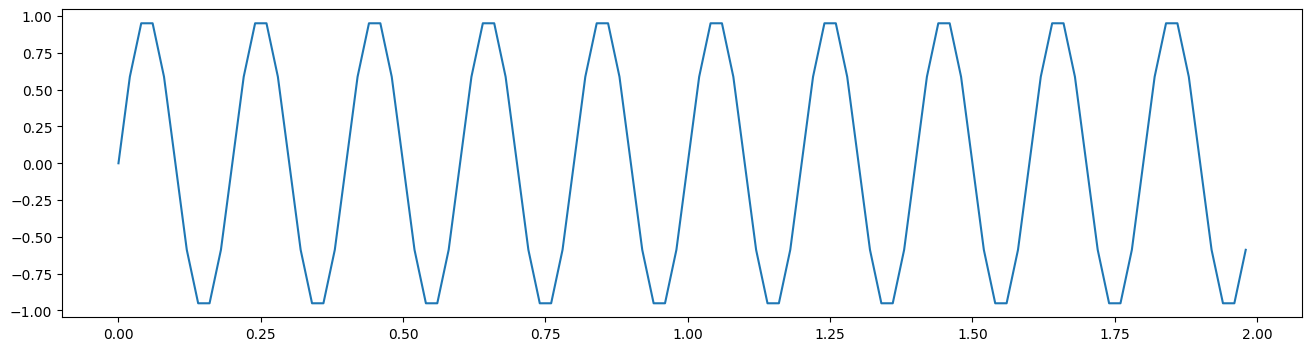

In [20]:
freq = 50
time = np.arange(0, 65536, 1/freq)
signal = np.sin(2 * np.pi * 5 * time)
plt.figure(figsize=(16, 4))
sns.lineplot(x=time[:100], y=signal[:100])
